# G3 — NTN-B Princ 150535 (venc. 15/05/2035) — Linha A (Univariado)

**Feature de entrada:** Taxa Compra Manhã
**Alvo:** Taxa Compra Manhã (próximo dia útil)
**Período:** todo o histórico disponível do título (auto-descoberta dos .xls).

Arquivos esperados na pasta: `NTN-B_Principal_AAAA.xls` para cada ano
disponível (ex.: 2011, 2012, ..., 2025). Baixe em
https://www.tesourodireto.com.br/produtos/dados-sobre-titulos/historico-de-precos-e-taxas

# Setup Google Colab + Google Drive

Faça upload dos arquivos NTN-B_Principal_*.xls para uma pasta no seu Drive
(ex.: MyDrive/seminario3/dados/) antes de rodar.

In [ ]:
import os, sys, subprocess
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'xlrd', 'openpyxl'],
                   check=False)
    from google.colab import drive
    drive.mount('/content/drive')
    # >>> AJUSTE este caminho para a pasta onde estão seus .xls <<<
    DATA_DIR = '/content/drive/MyDrive/seminario3/dados'
    os.chdir(DATA_DIR)
else:
    DATA_DIR = os.getcwd()

import xlrd
print('xlrd version:', xlrd.__version__)
print('DATA_DIR:', DATA_DIR)
print('Arquivos:', sorted([f for f in os.listdir(DATA_DIR) if f.lower().endswith(('.xls', '.xlsx'))]))

Mounted at /content/drive
xlrd version: 2.0.2
DATA_DIR: /content/drive/MyDrive/seminario3/dados
Arquivos: ['NTN-B_Principal_2012.xls', 'NTN-B_Principal_2013.xls', 'NTN-B_Principal_2014.xls', 'NTN-B_Principal_2015.xls', 'NTN-B_Principal_2016.xls', 'NTN-B_Principal_2017.xls', 'NTN-B_Principal_2018.xls', 'NTN-B_Principal_2019.xls', 'NTN-B_Principal_2020.xls', 'NTN-B_Principal_2021.xls', 'NTN-B_Principal_2022.xls', 'NTN-B_Principal_2023.xls', 'NTN-B_Principal_2024.xls', 'NTN-B_Principal_2026.xls', 'NTNBPrincipal_2010.xls', 'NTNBPrincipal_2011.xls']


## 0. Imports e reprodutibilidade

In [ ]:
import glob
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {DEVICE}")

Dispositivo: cpu


## 1. Carregamento — todo o histórico do 150535
O 150535 foi emitido em 2010. Tente baixar de 2010/2011 até o ano corrente.

In [ ]:
ABA = "NTN-B Princ 150535"
COLUNA = "Taxa Compra Manhã"

# Pasta dos dados — se rodando no Colab, DATA_DIR foi definido na célula de
# setup; caso contrário, usa a pasta atual.
DATA_DIR = globals().get("DATA_DIR", os.getcwd())
print(f"Procurando arquivos em: {DATA_DIR}")

arquivos = sorted(glob.glob(os.path.join(DATA_DIR, "NTN-B_Principal_*.xls"))) + \
           sorted(glob.glob(os.path.join(DATA_DIR, "NTN-B_Principal_*.xlsx")))
if not arquivos:
    raise FileNotFoundError(
        f"Nenhum arquivo NTN-B_Principal_*.xls encontrado em {DATA_DIR}."
    )

print(f"Arquivos detectados ({len(arquivos)}):")
for a in arquivos:
    print(f"  - {a}")

def ler_xls_direto(caminho, aba, header_row=1):
    """Lê um .xls diretamente via xlrd, contornando a checagem de versão do pandas."""
    import xlrd
    book = xlrd.open_workbook(caminho)
    if aba not in book.sheet_names():
        raise ValueError(f"Aba '{aba}' não encontrada. Abas: {book.sheet_names()}")
    sh = book.sheet_by_name(aba)
    headers = [str(sh.cell_value(header_row, c)).strip() for c in range(sh.ncols)]
    rows = []
    for r in range(header_row + 1, sh.nrows):
        row = []
        for c in range(sh.ncols):
            ct = sh.cell_type(r, c)
            v = sh.cell_value(r, c)
            if ct == xlrd.XL_CELL_DATE:
                v = xlrd.xldate.xldate_as_datetime(v, book.datemode)
            row.append(v)
        rows.append(row)
    return pd.DataFrame(rows, columns=headers)


partes = []
for nome in arquivos:
    ext = os.path.splitext(nome)[1].lower()
    try:
        if ext == ".xls":
            df_raw = ler_xls_direto(nome, ABA, header_row=1)
        else:
            df_raw = pd.read_excel(nome, sheet_name=ABA, engine="openpyxl", header=1)
    except Exception as e:
        print(f"  ! pulei {nome}: {e}")
        continue
    if "Dia" not in df_raw.columns or COLUNA not in df_raw.columns:
        print(f"  ! {nome} sem colunas esperadas — pulando ({list(df_raw.columns)[:5]}...)")
        continue
    df_raw = df_raw[["Dia", COLUNA]].copy()
    df_raw.columns = ["Data", "Taxa"]
    df_raw["Data"] = pd.to_datetime(df_raw["Data"], dayfirst=True, errors="coerce")
    df_raw["Taxa"] = pd.to_numeric(df_raw["Taxa"], errors="coerce")
    df_raw.dropna(inplace=True)
    partes.append(df_raw)

df = (
    pd.concat(partes)
    .drop_duplicates(subset=["Data"])
    .sort_values("Data")
    .reset_index(drop=True)
)
print(f"\nPeríodo:    {df['Data'].min().date()}  →  {df['Data'].max().date()}")
print(f"Observações: {len(df)} dias úteis")
print(f"Taxa mín.:   {df['Taxa'].min()*100:.2f}%")
print(f"Taxa máx.:   {df['Taxa'].max()*100:.2f}%")
print(f"Taxa média:  {df['Taxa'].mean()*100:.2f}%")
df.head()

Procurando arquivos em: /content/drive/MyDrive/seminario3/dados
Arquivos detectados (14):
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2012.xls
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2013.xls
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2014.xls
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2015.xls
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2016.xls
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2017.xls
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2018.xls
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2019.xls
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2020.xls
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2021.xls
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2022.xls
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2023.xls
  - /content/drive/MyDrive/seminario3/dados/NTN-B_Principal_2024.xls
  - /content/

,Data,Taxa
0,2012-01-02,0.0555
1,2012-01-03,0.0551
2,2012-01-04,0.0549
3,2012-01-05,0.0557
4,2012-01-06,0.0553


### Visualização da série completa

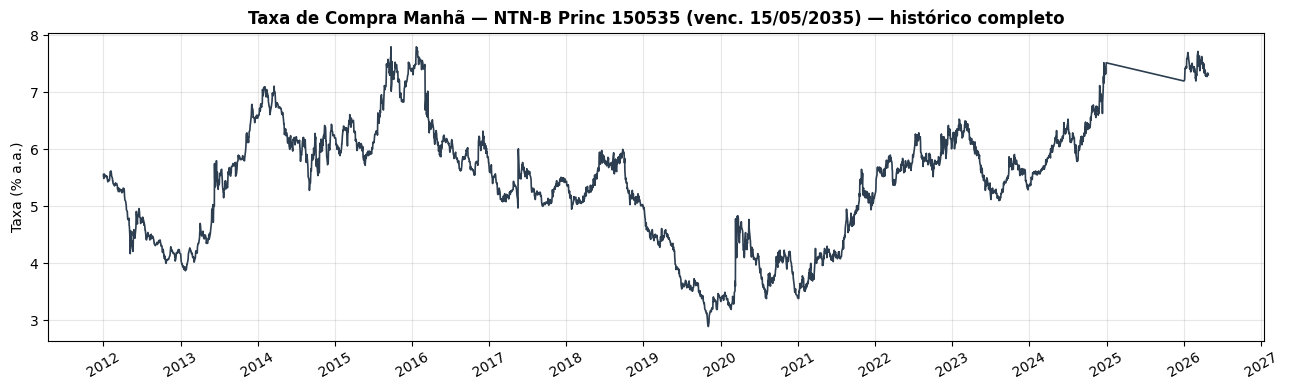

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["Data"], df["Taxa"] * 100, color="#2c3e50", lw=1.2)
ax.set_title(
    f"Taxa de Compra Manhã — {ABA} (venc. 15/05/2035) — histórico completo",
    fontweight="bold",
)
ax.set_ylabel("Taxa (% a.a.)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Pré-processamento — janelas, normalização e split cronológico

In [ ]:
JANELA = 20
HORIZONTE = 1
SPLIT_TREINO = 0.80

serie = df["Taxa"].values.astype(np.float32).reshape(-1, 1)
n_treino = int(len(serie) * SPLIT_TREINO)
treino_raw = serie[:n_treino]
teste_raw = serie[n_treino:]

scaler = MinMaxScaler(feature_range=(0, 1))
treino_norm = scaler.fit_transform(treino_raw)
teste_norm = scaler.transform(teste_raw)

print(f"Total: {len(serie)}  | Treino: {n_treino}  | Teste: {len(serie)-n_treino}")
print(f"Corte treino/teste: {df['Data'].iloc[n_treino].date()}")


def criar_janelas(dados, janela=JANELA, horizonte=HORIZONTE):
    X, y = [], []
    for i in range(len(dados) - janela - horizonte + 1):
        X.append(dados[i : i + janela])
        y.append(dados[i + janela + horizonte - 1])
    return (
        torch.tensor(np.array(X), dtype=torch.float32),
        torch.tensor(np.array(y), dtype=torch.float32),
    )


X_tr, y_tr = criar_janelas(treino_norm)
X_te, y_te = criar_janelas(teste_norm)
print(f"X_tr: {tuple(X_tr.shape)}  X_te: {tuple(X_te.shape)}")

Total: 3319  | Treino: 2655  | Teste: 664
Corte treino/teste: 2022-08-25
X_tr: (2635, 20, 1)  X_te: (644, 20, 1)


### Visualização do corte treino/teste

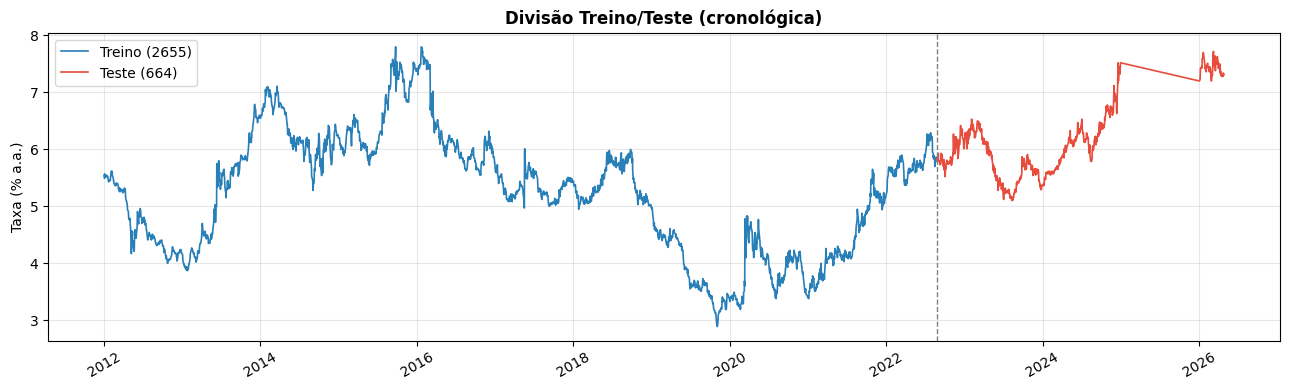

In [ ]:
data_corte = df["Data"].iloc[n_treino]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(
    df["Data"][:n_treino],
    df["Taxa"][:n_treino] * 100,
    color="#2980b9",
    lw=1.2,
    label=f"Treino ({n_treino})",
)
ax.plot(
    df["Data"][n_treino:],
    df["Taxa"][n_treino:] * 100,
    color="#e74c3c",
    lw=1.2,
    label=f"Teste ({len(serie)-n_treino})",
)
ax.axvline(data_corte, color="gray", ls="--", lw=1)
ax.set_title("Divisão Treino/Teste (cronológica)", fontweight="bold")
ax.set_ylabel("Taxa (% a.a.)")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. Modelos — RNN, LSTM, GRU

In [ ]:
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.0
INPUT_SIZE = 1
OUTPUT_SIZE = 1


class ModeloRNN(nn.Module):
    def __init__(self, hidden=HIDDEN_SIZE, camadas=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.rnn = nn.RNN(
            INPUT_SIZE,
            hidden,
            num_layers=camadas,
            batch_first=True,
            dropout=dropout if camadas > 1 else 0.0,
            nonlinearity="tanh",
        )
        self.fc = nn.Linear(hidden, OUTPUT_SIZE)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


class ModeloLSTM(nn.Module):
    def __init__(self, hidden=HIDDEN_SIZE, camadas=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            INPUT_SIZE,
            hidden,
            num_layers=camadas,
            batch_first=True,
            dropout=dropout if camadas > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden, OUTPUT_SIZE)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class ModeloGRU(nn.Module):
    def __init__(self, hidden=HIDDEN_SIZE, camadas=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.gru = nn.GRU(
            INPUT_SIZE,
            hidden,
            num_layers=camadas,
            batch_first=True,
            dropout=dropout if camadas > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden, OUTPUT_SIZE)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


for Cls in [ModeloRNN, ModeloLSTM, ModeloGRU]:
    n_params = sum(p.numel() for p in Cls().parameters() if p.requires_grad)
    print(f"{Cls.__name__:<12}: {n_params:,} parâmetros")

ModeloRNN   : 4,353 parâmetros
ModeloLSTM  : 17,217 parâmetros
ModeloGRU   : 12,929 parâmetros


## 4. Treinamento

In [ ]:
EPOCHS = 150
BATCH_SIZE = 32
LR = 1e-3
CLIP_GRAD = 1.0


def treinar(
    ModelClass,
    X_tr,
    y_tr,
    X_te,
    y_te,
    scaler_local,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    lr=LR,
    clip=CLIP_GRAD,
    verbose=True,
):
    modelo = ModelClass().to(DEVICE)
    X_tr, y_tr = X_tr.to(DEVICE), y_tr.to(DEVICE)
    X_te, y_te = X_te.to(DEVICE), y_te.to(DEVICE)

    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)
    crit = nn.MSELoss()

    hist_tr, hist_te = [], []
    n = len(X_tr)
    for ep in range(epochs):
        modelo.train()
        idx = torch.randperm(n)
        for i in range(0, n, batch):
            xb, yb = X_tr[idx[i : i + batch]], y_tr[idx[i : i + batch]]
            opt.zero_grad()
            loss = crit(modelo(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), clip)
            opt.step()
        modelo.eval()
        with torch.no_grad():
            loss_tr = crit(modelo(X_tr), y_tr).item()
            loss_te = crit(modelo(X_te), y_te).item()
        hist_tr.append(loss_tr)
        hist_te.append(loss_te)
        sched.step(loss_te)
        if verbose and (ep + 1) % 30 == 0:
            print(f"  ep {ep+1:4d} | tr={loss_tr:.6f}  te={loss_te:.6f}")

    modelo.eval()
    with torch.no_grad():
        preds_norm = modelo(X_te).cpu().numpy()
    preds = scaler_local.inverse_transform(preds_norm).flatten()
    real = scaler_local.inverse_transform(y_te.cpu().numpy()).flatten()
    return {"modelo": modelo, "hist_tr": hist_tr, "hist_te": hist_te,
            "preds": preds, "real": real}


resultados = {}
for nome, Cls in [("RNN", ModeloRNN), ("LSTM", ModeloLSTM), ("GRU", ModeloGRU)]:
    print(f"\n{'='*40}\n  {nome}\n{'='*40}")
    resultados[nome] = treinar(Cls, X_tr, y_tr, X_te, y_te, scaler)
print("\nTreinamento concluído.")


  RNN
  ep   30 | tr=0.000317  te=0.000300
  ep   60 | tr=0.000292  te=0.000264
  ep   90 | tr=0.000284  te=0.000268
  ep  120 | tr=0.000280  te=0.000248
  ep  150 | tr=0.000282  te=0.000249

  LSTM
  ep   30 | tr=0.000422  te=0.000320
  ep   60 | tr=0.000304  te=0.000297
  ep   90 | tr=0.000280  te=0.000249
  ep  120 | tr=0.000276  te=0.000249
  ep  150 | tr=0.000275  te=0.000247

  GRU
  ep   30 | tr=0.000335  te=0.000298
  ep   60 | tr=0.000292  te=0.000287
  ep   90 | tr=0.000277  te=0.000246
  ep  120 | tr=0.000276  te=0.000245
  ep  150 | tr=0.000277  te=0.000252

Treinamento concluído.


## 5. Métricas e baseline Naive

In [ ]:
print(f"{'Modelo':<12} {'RMSE':>10} {'MAE':>10} {'MAPE (%)':>12}")
print("-" * 46)
for nome, res in resultados.items():
    r, p = res["real"], res["preds"]
    res["rmse"] = float(np.sqrt(mean_squared_error(r, p)))
    res["mae"] = float(mean_absolute_error(r, p))
    res["mape"] = float(np.mean(np.abs((r - p) / r)) * 100)
    print(f"{nome:<12} {res['rmse']:>10.6f} {res['mae']:>10.6f} {res['mape']:>11.2f}%")

real = resultados["RNN"]["real"]
serie_teste_real = scaler.inverse_transform(teste_norm).flatten()
naive_pred = serie_teste_real[JANELA - 1 : JANELA - 1 + len(real)]
rmse_naive = float(np.sqrt(mean_squared_error(real, naive_pred)))
mae_naive = float(mean_absolute_error(real, naive_pred))
mape_naive = float(np.mean(np.abs((real - naive_pred) / real)) * 100)
print(f"{'Naive (t-1)':<12} {rmse_naive:>10.6f} {mae_naive:>10.6f} {mape_naive:>11.2f}%")

Modelo             RMSE        MAE     MAPE (%)
----------------------------------------------
RNN            0.000774   0.000557        0.90%
LSTM           0.000771   0.000557        0.90%
GRU            0.000779   0.000567        0.91%
Naive (t-1)    0.000788   0.000569        0.92%


## 6. Curvas de loss e previsão vs. real

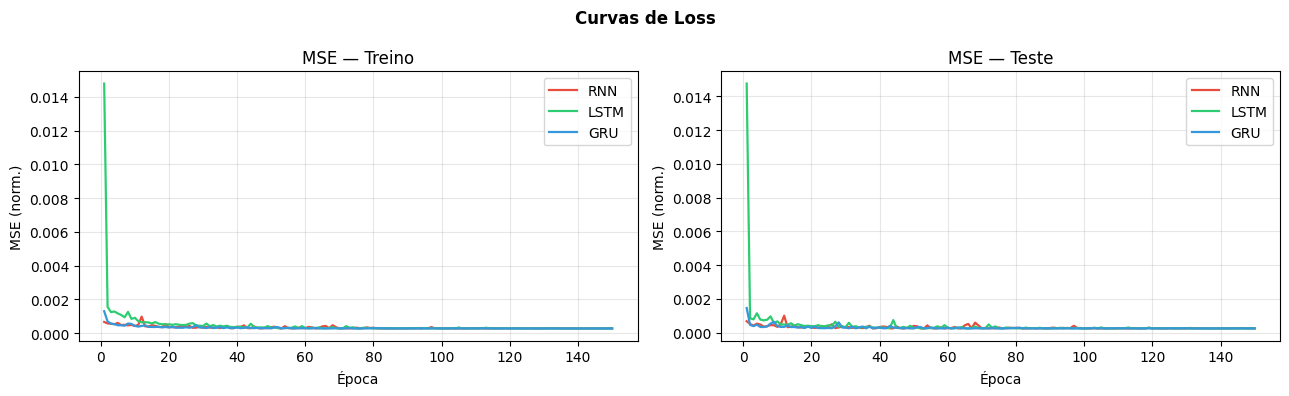

In [ ]:
cor = {"RNN": "#e74c3c", "LSTM": "#2ecc71", "GRU": "#3498db"}
epocas = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Curvas de Loss", fontweight="bold")
for ax, chave, titulo in [
    (axes[0], "hist_tr", "MSE — Treino"),
    (axes[1], "hist_te", "MSE — Teste"),
]:
    for nome, res in resultados.items():
        ax.plot(epocas, res[chave], color=cor[nome], lw=1.6, label=nome)
    ax.set_title(titulo)
    ax.set_xlabel("Época")
    ax.set_ylabel("MSE (norm.)")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_g3.png", dpi=150, bbox_inches="tight")
plt.show()

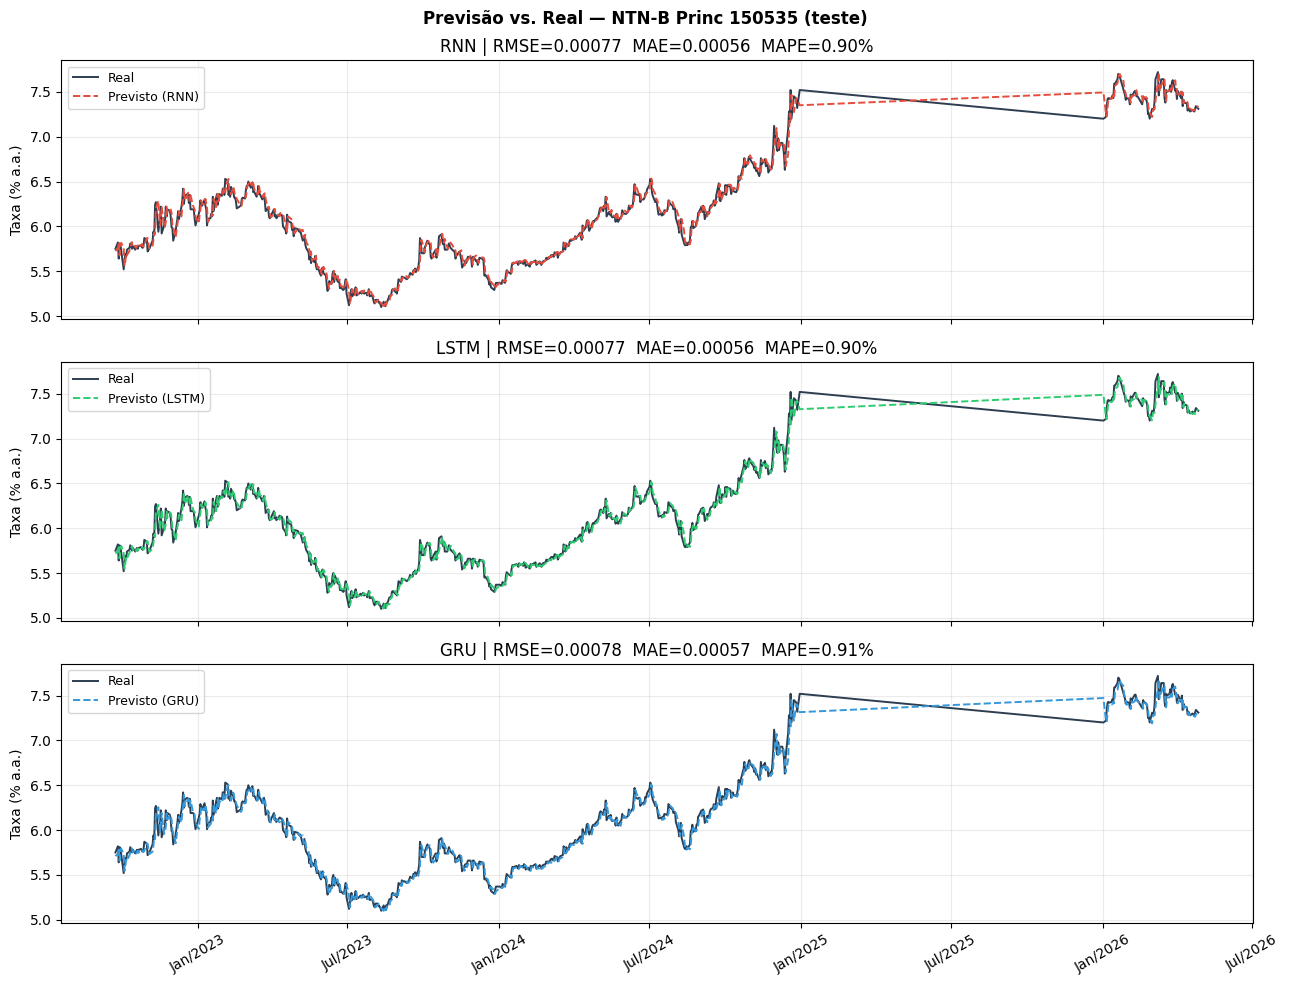

In [ ]:
datas_teste = (
    df["Data"].iloc[n_treino + JANELA : n_treino + JANELA + len(real)].values
)
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle(f"Previsão vs. Real — {ABA} (teste)", fontweight="bold")
for ax, (nome, res) in zip(axes, resultados.items()):
    ax.plot(datas_teste, res["real"] * 100, color="#2c3e50", lw=1.4, label="Real")
    ax.plot(
        datas_teste,
        res["preds"] * 100,
        color=cor[nome],
        lw=1.4,
        ls="--",
        label=f"Previsto ({nome})",
    )
    ax.set_title(
        f"{nome} | RMSE={res['rmse']:.5f}  MAE={res['mae']:.5f}  MAPE={res['mape']:.2f}%"
    )
    ax.set_ylabel("Taxa (% a.a.)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.25)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("previsoes_g3.png", dpi=150, bbox_inches="tight")
plt.show()

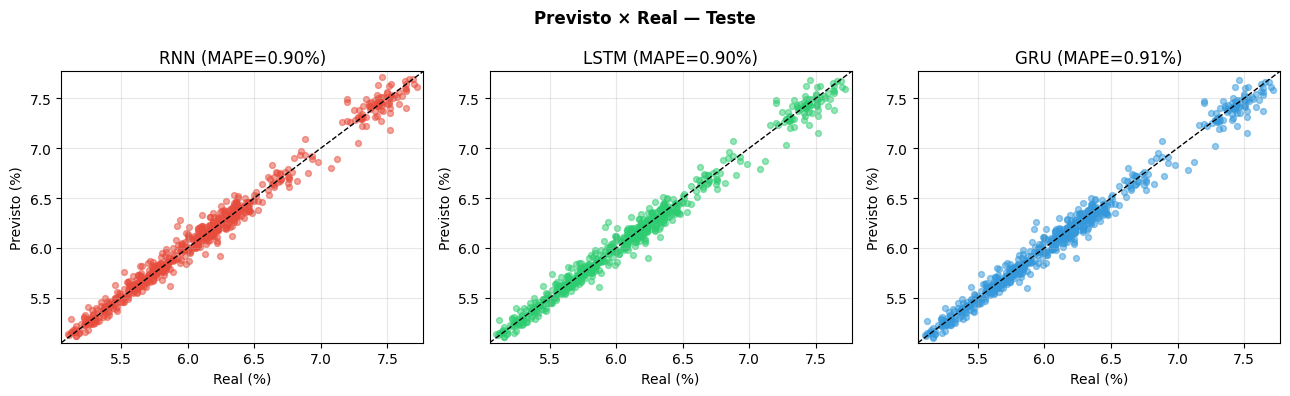

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Previsto × Real — Teste", fontweight="bold")
for ax, (nome, res) in zip(axes, resultados.items()):
    r, p = res["real"] * 100, res["preds"] * 100
    ax.scatter(r, p, alpha=0.5, s=18, color=cor[nome])
    lim = [min(r.min(), p.min()) - 0.05, max(r.max(), p.max()) + 0.05]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_title(f"{nome} (MAPE={res['mape']:.2f}%)")
    ax.set_xlabel("Real (%)")
    ax.set_ylabel("Previsto (%)")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("scatter_g3.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Experimento do grupo — variar a JANELA

Linha A: PDF pede variar **um parâmetro** indicado na tabela. Para G3,
vamos sweep da janela em [5, 10, 20, 40, 60] usando o melhor modelo.


--- JANELA=5  (X_tr=(2650, 5, 1)) ---
  RNN   RMSE=0.000806  MAPE=0.96%
  LSTM  RMSE=0.000797  MAPE=0.95%
  GRU   RMSE=0.000768  MAPE=0.90%

--- JANELA=10  (X_tr=(2645, 10, 1)) ---
  RNN   RMSE=0.000768  MAPE=0.90%
  LSTM  RMSE=0.000771  MAPE=0.90%
  GRU   RMSE=0.000775  MAPE=0.91%

--- JANELA=20  (X_tr=(2635, 20, 1)) ---
  RNN   RMSE=0.000772  MAPE=0.90%
  LSTM  RMSE=0.000772  MAPE=0.90%
  GRU   RMSE=0.000769  MAPE=0.90%

--- JANELA=40  (X_tr=(2615, 40, 1)) ---
  RNN   RMSE=0.000793  MAPE=0.93%
  LSTM  RMSE=0.000774  MAPE=0.90%
  GRU   RMSE=0.000773  MAPE=0.90%

--- JANELA=60  (X_tr=(2595, 60, 1)) ---
  RNN   RMSE=0.000744  MAPE=0.88%
  LSTM  RMSE=0.000741  MAPE=0.87%
  GRU   RMSE=0.000739  MAPE=0.87%

Tabela do experimento:
Modelo       GRU      LSTM       RNN
JANELA                              
5       0.000768  0.000797  0.000806
10      0.000775  0.000771  0.000768
20      0.000769  0.000772  0.000772
40      0.000773  0.000774  0.000793
60      0.000739  0.000741  0.000744


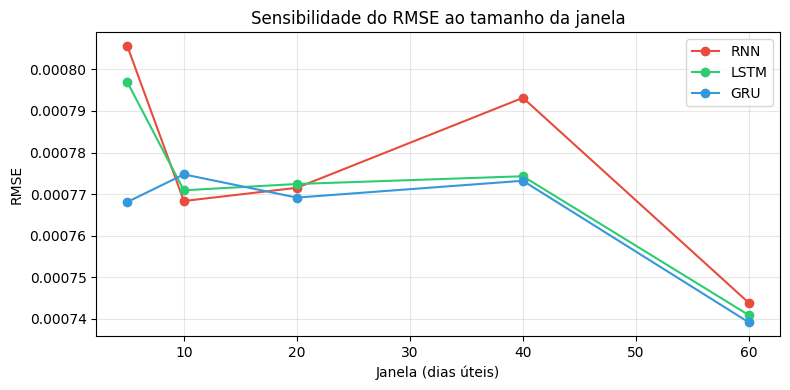

In [ ]:
JANELAS_TESTE = [5, 10, 20, 40, 60]
linhas = []
for j in JANELAS_TESTE:
    Xtr_j, ytr_j = criar_janelas(treino_norm, janela=j)
    Xte_j, yte_j = criar_janelas(teste_norm, janela=j)
    print(f"\n--- JANELA={j}  (X_tr={tuple(Xtr_j.shape)}) ---")
    for nome, Cls in [("RNN", ModeloRNN), ("LSTM", ModeloLSTM), ("GRU", ModeloGRU)]:
        res_j = treinar(Cls, Xtr_j, ytr_j, Xte_j, yte_j, scaler, verbose=False)
        rmse = float(np.sqrt(mean_squared_error(res_j["real"], res_j["preds"])))
        mape = float(
            np.mean(np.abs((res_j["real"] - res_j["preds"]) / res_j["real"])) * 100
        )
        linhas.append({"JANELA": j, "Modelo": nome, "RMSE": rmse, "MAPE": mape})
        print(f"  {nome:<5} RMSE={rmse:.6f}  MAPE={mape:.2f}%")

tab_exp = pd.DataFrame(linhas)
print("\nTabela do experimento:")
print(tab_exp.pivot(index="JANELA", columns="Modelo", values="RMSE"))

fig, ax = plt.subplots(figsize=(8, 4))
for nome in ["RNN", "LSTM", "GRU"]:
    sub = tab_exp[tab_exp["Modelo"] == nome]
    ax.plot(sub["JANELA"], sub["RMSE"], "-o", color=cor[nome], label=nome)
ax.set_xlabel("Janela (dias úteis)")
ax.set_ylabel("RMSE")
ax.set_title("Sensibilidade do RMSE ao tamanho da janela")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("experimento_janela_g3.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Marcação a Mercado — Quartis móveis

Compra (taxa>Q3): 1141  (34.4%)
Neutro          : 1139  (34.3%)
Evitar (taxa<Q1): 1039  (31.3%)
Taxa média compra: 5.7628%
Taxa média geral : 5.4139%
Ganho médio extra: +0.3489 p.p.


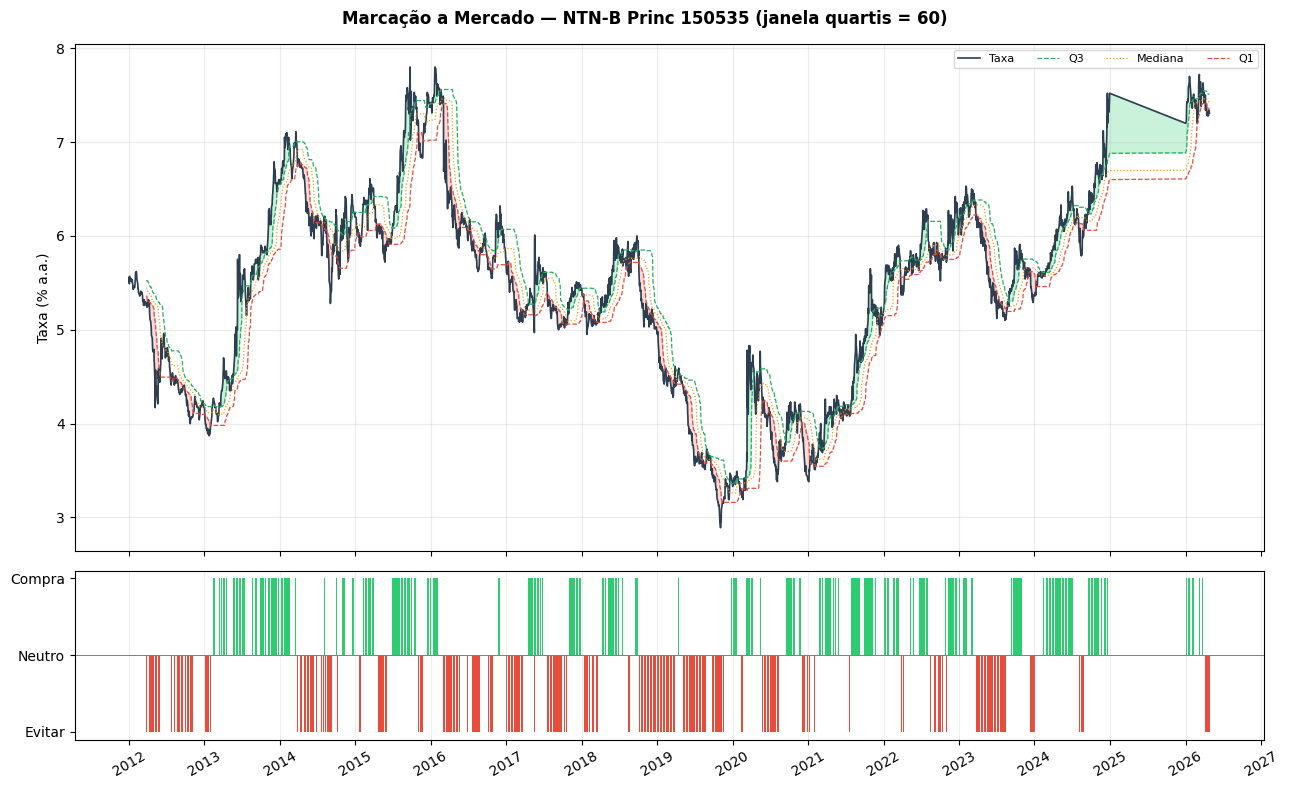

In [ ]:
JANELA_QUARTIL = 60
taxa_serie = df["Taxa"].copy()
q1 = taxa_serie.rolling(JANELA_QUARTIL, min_periods=JANELA_QUARTIL).quantile(0.25)
q2 = taxa_serie.rolling(JANELA_QUARTIL, min_periods=JANELA_QUARTIL).quantile(0.50)
q3 = taxa_serie.rolling(JANELA_QUARTIL, min_periods=JANELA_QUARTIL).quantile(0.75)

sinal = pd.Series(0, index=df.index)
sinal[taxa_serie > q3] = 1
sinal[taxa_serie < q1] = -1

n_compra = int((sinal == 1).sum())
n_evitar = int((sinal == -1).sum())
n_neutro = int((sinal == 0).sum())
print(f"Compra (taxa>Q3): {n_compra}  ({n_compra/len(df)*100:.1f}%)")
print(f"Neutro          : {n_neutro}  ({n_neutro/len(df)*100:.1f}%)")
print(f"Evitar (taxa<Q1): {n_evitar}  ({n_evitar/len(df)*100:.1f}%)")
print(f"Taxa média compra: {taxa_serie[sinal==1].mean()*100:.4f}%")
print(f"Taxa média geral : {taxa_serie.mean()*100:.4f}%")
print(
    f"Ganho médio extra: +{(taxa_serie[sinal==1].mean()-taxa_serie.mean())*100:.4f} p.p."
)

fig, axes = plt.subplots(
    2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
fig.suptitle(
    f"Marcação a Mercado — {ABA} (janela quartis = {JANELA_QUARTIL})",
    fontweight="bold",
)
ax = axes[0]
ax.plot(df["Data"], taxa_serie * 100, color="#2c3e50", lw=1.2, label="Taxa")
ax.plot(df["Data"], q3 * 100, color="#27ae60", lw=0.9, ls="--", label="Q3")
ax.plot(df["Data"], q2 * 100, color="#f39c12", lw=0.9, ls=":", label="Mediana")
ax.plot(df["Data"], q1 * 100, color="#e74c3c", lw=0.9, ls="--", label="Q1")
ax.fill_between(
    df["Data"], q3 * 100, taxa_serie * 100, where=(taxa_serie > q3),
    color="#2ecc71", alpha=0.25,
)
ax.fill_between(
    df["Data"], taxa_serie * 100, q1 * 100, where=(taxa_serie < q1),
    color="#e74c3c", alpha=0.20,
)
ax.set_ylabel("Taxa (% a.a.)")
ax.legend(fontsize=8, ncol=4)
ax.grid(alpha=0.25)

ax2 = axes[1]
cores_sinal = sinal.map({1: "#2ecc71", 0: "#bdc3c7", -1: "#e74c3c"})
ax2.bar(df["Data"], sinal, color=cores_sinal, width=1.5)
ax2.axhline(0, color="gray", lw=0.7)
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(["Evitar", "Neutro", "Compra"])
ax2.grid(alpha=0.2, axis="x")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("marcacao_g3.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Sinal combinado — modelo + quartil

Melhor modelo (RMSE): LSTM
Dias com sinal combinado: 264 de 644
Taxa média no sinal combinado: 6.3208%
Taxa média no teste          : 6.1358%
Ganho médio: +0.1850 p.p.


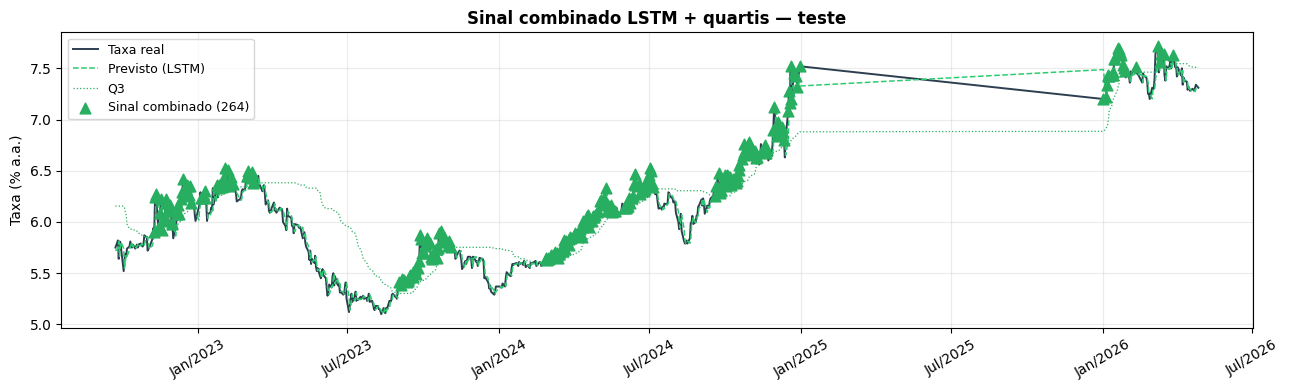

In [ ]:
melhor_nome = min(resultados, key=lambda k: resultados[k]["rmse"])
preds_melhor = resultados[melhor_nome]["preds"]
print(f"Melhor modelo (RMSE): {melhor_nome}")

n_preds = len(preds_melhor)
idx_te = list(range(n_treino + JANELA, n_treino + JANELA + n_preds))
datas_te = df["Data"].iloc[idx_te]
taxa_te = df["Taxa"].iloc[idx_te].values
q3_te = q3.iloc[idx_te].values
q1_te = q1.iloc[idx_te].values

sinal_neural = preds_melhor > q3_te
sinal_quartil = taxa_te > q3_te
sinal_combinado = sinal_neural & sinal_quartil
n_comb = int(sinal_combinado.sum())

print(f"Dias com sinal combinado: {n_comb} de {n_preds}")
if n_comb > 0:
    print(
        f"Taxa média no sinal combinado: {taxa_te[sinal_combinado].mean()*100:.4f}%"
    )
    print(f"Taxa média no teste          : {taxa_te.mean()*100:.4f}%")
    print(
        f"Ganho médio: +{(taxa_te[sinal_combinado].mean()-taxa_te.mean())*100:.4f} p.p."
    )

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(datas_te, taxa_te * 100, color="#2c3e50", lw=1.4, label="Taxa real")
ax.plot(
    datas_te, preds_melhor * 100, color=cor[melhor_nome], lw=1.1, ls="--",
    label=f"Previsto ({melhor_nome})",
)
ax.plot(datas_te, q3_te * 100, color="#27ae60", lw=0.9, ls=":", label="Q3")
if n_comb > 0:
    ax.scatter(
        datas_te.values[sinal_combinado],
        taxa_te[sinal_combinado] * 100,
        color="#27ae60", s=60, marker="^", zorder=5,
        label=f"Sinal combinado ({n_comb})",
    )
ax.set_title(f"Sinal combinado {melhor_nome} + quartis — teste", fontweight="bold")
ax.set_ylabel("Taxa (% a.a.)")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("sinal_combinado_g3.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Resumo por regime

In [ ]:
regimes = {
    "Compra (taxa > Q3)": taxa_serie[sinal == 1],
    "Neutro (Q1-Q3)": taxa_serie[sinal == 0],
    "Evitar (taxa < Q1)": taxa_serie[sinal == -1],
}
print(f"{'Regime':<22} {'Dias':>6} {'Mín':>8} {'Med':>8} {'Máx':>8} {'Média':>8}")
for nome_r, vals in regimes.items():
    if len(vals) == 0:
        continue
    print(
        f"{nome_r:<22} {len(vals):>6} "
        f"{vals.min()*100:>7.4f}% {vals.median()*100:>7.4f}% "
        f"{vals.max()*100:>7.4f}% {vals.mean()*100:>7.4f}%"
    )

Regime                   Dias      Mín      Med      Máx    Média
Compra (taxa > Q3)       1141  3.3800%  5.8400%  7.8000%  5.7628%
Neutro (Q1-Q3)           1139  3.1600%  5.5600%  7.5600%  5.3569%
Evitar (taxa < Q1)       1039  2.8900%  5.2200%  7.4100%  5.0933%
